In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv("business_sales.csv")

In [5]:
df

,Date,Advertising_Expense,Discount_Percent,Customers,Sales
0,2021-01-01,21854.31,6.54,697,125968.48
1,2021-01-02,47782.14,6.17,100,122968.88
2,2021-01-03,37939.73,22.66,143,112651.77
3,2021-01-04,31939.63,6.24,244,85786.51
4,2021-01-05,12020.84,6.80,106,57146.45
...,...,...,...,...,...
1995,2026-06-19,34562.98,11.05,337,116403.05
1996,2026-06-20,48047.66,8.36,609,162208.36
1997,2026-06-21,8103.11,9.86,766,91594.38
1998,2026-06-22,7567.46,13.25,308,44135.18


In [3]:
df.head()

,Date,Advertising_Expense,Discount_Percent,Customers,Sales
0,2021-01-01,21854.31,6.54,697,125968.48
1,2021-01-02,47782.14,6.17,100,122968.88
2,2021-01-03,37939.73,22.66,143,112651.77
3,2021-01-04,31939.63,6.24,244,85786.51
4,2021-01-05,12020.84,6.80,106,57146.45


In [4]:
df.tail()

,Date,Advertising_Expense,Discount_Percent,Customers,Sales
1995,2026-06-19,34562.98,11.05,337,116403.05
1996,2026-06-20,48047.66,8.36,609,162208.36
1997,2026-06-21,8103.11,9.86,766,91594.38
1998,2026-06-22,7567.46,13.25,308,44135.18
1999,2026-06-23,17698.42,4.03,305,79230.01


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 2000 non-null   object 
 1   Advertising_Expense  2000 non-null   float64
 2   Discount_Percent     2000 non-null   float64
 3   Customers            2000 non-null   int64  
 4   Sales                2000 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 78.3+ KB


In [7]:
df.isnull().sum()

Date                   0
Advertising_Expense    0
Discount_Percent       0
Customers              0
Sales                  0
dtype: int64

In [8]:
df.describe()

,Advertising_Expense,Discount_Percent,Customers,Sales
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,27438.661680,12.409745,537.273000,112968.331320
std,13149.485872,7.214545,266.269734,37255.120831
min,5144.820000,0.000000,80.000000,14417.600000
25%,15712.095000,6.267500,300.000000,85082.040000
50%,27830.810000,12.315000,538.000000,113617.955000
75%,38780.545000,18.720000,764.000000,139950.555000
max,49987.300000,24.990000,999.000000,208108.380000


In [12]:
df["Date"]=pd.to_datetime(df["Date"])

In [17]:
x = df[["Advertising_Expense", "Discount_Percent", "Customers"]]
y = df["Sales"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [20]:
model=LinearRegression()

In [21]:
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
y_pred = model.predict(X_test)
y_pred

array([166882.98524356,  78055.61558154, 168740.94198373, 141764.77569105,
       109038.98829557,  32905.69195132,  54863.67963869, 124855.48156334,
       118401.63697012,  55888.22630489, 103578.31763414, 108902.18508368,
        99976.70480189,  99770.13666333,  51085.19424207, 145550.97877462,
        74793.8194736 ,  67447.76886901,  95269.01976434, 183255.21701948,
        76515.36741514, 133908.04607538, 168134.61348941, 142190.39016262,
       156315.72928336,  65745.9066861 ,  84851.61345935, 125613.5234603 ,
        94414.56337587,  76055.1488371 ,  33097.4500818 ,  60931.79756546,
        74284.51449656, 107439.67536674, 131249.74952265, 141220.44617944,
       142462.71675594,  99979.97619413,  89180.90315287,  68203.29460298,
        87984.78229984, 129162.73167338,  90034.53545895,  85101.21792781,
        93501.17329139, 150208.84568493, 148494.66044665, 117136.73541836,
       136048.1277603 ,  84696.56889759, 106803.83953625, 177301.24136493,
       150109.67693467, 1

In [23]:
result = pd.DataFrame({"Actual_sales": y_test, "Predicted_sales": y_pred})
print("\nActual_sales vs Predicted_sales")
print(result.head(10))


Actual_sales vs Predicted_sales
      Actual_sales  Predicted_sales
1860     163507.08    166882.985244
353       82966.61     78055.615582
1333     170527.79    168740.941984
905      141609.08    141764.775691
1289     118924.86    109038.988296
1273      32332.24     32905.691951
938       42551.16     54863.679639
1731     141713.85    124855.481563
65       133587.96    118401.636970
1323      46231.78     55888.226305


In [24]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("M. S. E : ", mse)
print("R2 score : ", r2)

M. S. E :  109483689.57319479
R2 score :  0.92235474312562


In [25]:
new_data = [[30000, 10, 500]]
future_sales = model.predict(new_data)


C:\Users\Wilson\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [26]:
print("Predicted Sales:", future_sales[0])

Predicted Sales: 115804.39993738645


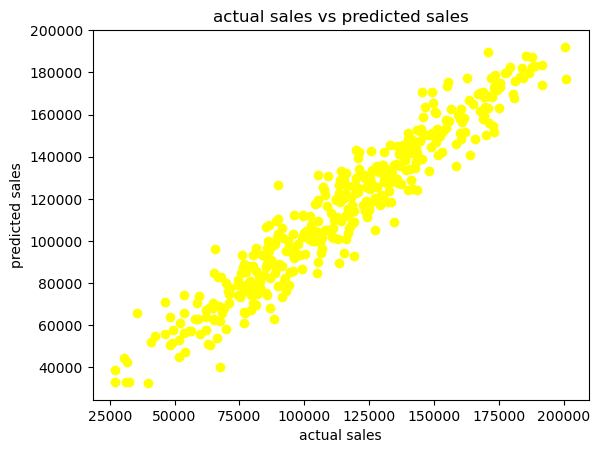

In [27]:
plt.scatter(y_test, y_pred,color="yellow")
plt.xlabel("actual sales")
plt.ylabel("predicted sales")
plt.title("actual sales vs predicted sales")
plt.show()